In [158]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [159]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [160]:
class Model(nn.Module):
    def __init__(self, in_features=75, h1=64, h2=32, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x
    
class PunchLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, out_features=3, dropout=0.3):
        super(PunchLSTM, self).__init__()
        # input_size = 6 coords + 1 hand type
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len=15, input_size=7)
        lstm_out, _ = self.lstm(x)  # lstm_out: (batch_size, seq_len, hidden_size)
        x = lstm_out[:, -1, :]      # take the last frame output
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [161]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'x2', 'y2'])
df = df.drop('name', axis=1)
df

n = 15  # rows per sequence
num_groups = df.shape[0] // n

def make_relative_per_landmark(group):
    for i in range(1, 3):
        x_col, y_col = f'x{i}', f'y{i}'
        x0, y0= group.iloc[0][[x_col, y_col]]
        group[x_col] = group[x_col] - x0
        group[y_col] = group[y_col] - y0
    coords_array = group[[f'x{i}' for i in range(1, 3)] + [f'y{i}' for i in range(1, 3)]].to_numpy()
    coords_reshaped = coords_array.reshape(len(group), 2, 2)
    
    distances = np.linalg.norm(coords_reshaped, axis=2)
    max_distance = distances.max()
    coords_normalized = coords_reshaped / max_distance if max_distance > 0 else coords_reshaped

    group[[f'x{i}' for i in range(1, 3)] + [f'y{i}' for i in range(1, 3)]] = coords_normalized.reshape(len(group), 4)
    
    return group

groups = [make_relative_per_landmark(df.iloc[i*n:(i+1)*n].copy()) for i in range(num_groups)]
df_rel = pd.concat(groups, ignore_index=True)

df = df_rel

df.shape

(1095, 5)

In [162]:
df['hand'] = df['type'].str.extract(r'(left|right)$')
df['hand_flag'] = df['hand'].map({'left': 1, 'right': 0})


df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

In [163]:
df = df.drop('hand', axis=1)

In [164]:
df['type'].value_counts()


type
0    450
1    448
2    197
Name: count, dtype: int64

In [165]:
import numpy as np

features = ['x1','y1','x2','y2','hand_flag']
seq_len = 15  # number of frames per sequence

# Trim the DataFrame to a multiple of seq_len
num_sequences = df.shape[0] // seq_len
df_trim = df.iloc[:num_sequences * seq_len]

# Extract feature values as NumPy array
arr = df_trim[features].values  # shape: (num_sequences * seq_len, 5)

# Reshape into sequences for LSTM
X = arr.reshape(num_sequences, seq_len, len(features))  # shape: (num_sequences, 15, 5)

# Handle labels (take first row's label for each sequence)
y_arr = df_trim['type'].values
y = y_arr.reshape(num_sequences, seq_len)[:, 0]

print("X shape:", X.shape)  # (num_sequences, 15, 5)
print("y shape:", y.shape)  # (num_sequences,)

X shape: (73, 15, 5)
y shape: (73,)


In [166]:
from sklearn.preprocessing import MinMaxScaler

num_sequences, seq_len, num_features = X.shape  # e.g., (num_sequences, 15, 5)

X_reshaped = X.reshape(-1, num_features)

# Scale features to [0,1]
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_reshaped)

# Reshape back to 3D for LSTM: (num_sequences, seq_len, num_features)
X = X_scaled.reshape(num_sequences, seq_len, num_features)

In [167]:
torch.manual_seed(42)
model = PunchLSTM()
model


PunchLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [168]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [169]:
print(X_train.shape, X_val.shape, X_test.shape)

(58, 15, 5) (7, 15, 5) (8, 15, 5)


In [170]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)


# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)
y_val = torch.LongTensor(y_val)

In [171]:
print(X_train.shape)  # should be (num_samples, num_features)
print(y_train.shape)  # should be (num_samples,) or (num_samples, 1)

torch.Size([58, 15, 5])
torch.Size([58])


In [172]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
)

In [173]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [174]:


epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for Xb, yb in train_loader:
        Xb, yb = Xb.float(), yb.long()
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.float(), yb.long()
            preds = model(Xb)
            val_running += criterion(preds, yb).item()
    val_loss = val_running / len(val_loader)

    if epoch > 10:
        scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


Epoch 0 | Train Loss: 1.066041 | Val Loss: 1.141877
Epoch 10 | Train Loss: 1.022761 | Val Loss: 0.952692
Epoch 20 | Train Loss: 0.823503 | Val Loss: 0.714495
Epoch 30 | Train Loss: 0.636140 | Val Loss: 0.808261
Epoch 40 | Train Loss: 0.432330 | Val Loss: 0.515323
Epoch 50 | Train Loss: 0.434168 | Val Loss: 1.575732
Epoch 60 | Train Loss: 0.397156 | Val Loss: 0.532244
Epoch 70 | Train Loss: 0.366253 | Val Loss: 0.432892
Epoch 80 | Train Loss: 0.351556 | Val Loss: 0.434297
Epoch 90 | Train Loss: 0.357005 | Val Loss: 0.434346


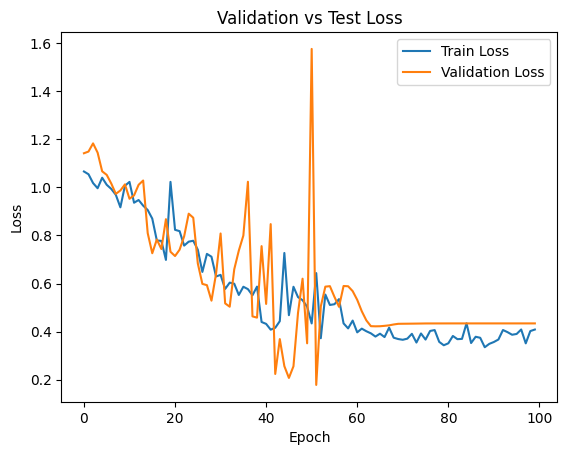

In [175]:
# plot the losses
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Validation vs Test Loss")
plt.show()

In [ ]:
# Convert to tensor and move to device
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import TensorDataset, DataLoader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32)

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb, yb
        y_pred = model(Xb)
        test_loss += criterion(y_pred, yb).item() * Xb.size(0)  # scale by batch size
        correct += (y_pred.argmax(dim=1) == yb).sum().item()
        total += yb.size(0)

test_loss /= total  # average loss per sample
accuracy = correct / total

print(f"Test Loss: {test_loss:.6f} | Test Accuracy: {accuracy:.2%}")


tensor(1.4504)

In [178]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)# shape: (num_samples, 15, 7)
y_test_tensor = torch.tensor(y_test, dtype=torch.long) # shape: (num_samples,)

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        x = X_test_tensor[i].unsqueeze(0)  # add batch dimension: (1, 15, 7)
        y_pred = model(x)                   # output: (1, num_classes)
        predicted_class = y_pred.argmax(dim=1).item()

        # Optional: map to string
        class_map = {0: "hook", 1: "uppercut", 2: "jab"}
        pred_label = class_map[predicted_class]
        true_label = class_map[y_test_tensor[i].item()]

        print(f"{i+1}.) Pred: {pred_label} ({predicted_class}) | True: {true_label} ({y_test_tensor[i].item()})")

        if predicted_class == y_test_tensor[i].item():
            correct += 1
        total += 1

print(f'We got {correct} out of {total} correct. Accuracy: {correct/total:.2%}')


1.) Pred: uppercut (1) | True: uppercut (1)
2.) Pred: hook (0) | True: hook (0)
3.) Pred: jab (2) | True: jab (2)
4.) Pred: jab (2) | True: uppercut (1)
5.) Pred: uppercut (1) | True: jab (2)
6.) Pred: uppercut (1) | True: hook (0)
7.) Pred: hook (0) | True: hook (0)
8.) Pred: uppercut (1) | True: uppercut (1)
We got 5 out of 8 correct. Accuracy: 62.50%


/var/folders/hx/vv3qzxpn2n73_w6r9j7ffdsc0000gn/T/ipykernel_27134/3090517180.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)# shape: (num_samples, 15, 7)
/var/folders/hx/vv3qzxpn2n73_w6r9j7ffdsc0000gn/T/ipykernel_27134/3090517180.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test_tensor = torch.tensor(y_test, dtype=torch.long) # shape: (num_samples,)


In [100]:
torch.save(model.state_dict(), "model_state.pt")